# NEURO-105: Project
## Mouse Cognition Study

## Question: Do mice with exercise wheels perform better on object recognition?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print("Libraries Loaded!")

Libraries Loaded!


In [ ]:
# Load the dataset
infile = "https://raw.githubusercontent.com/cgenomicslab/Courses/refs/heads/main/MScNeuro/2026/data/mouse_cognition.csv"
#infile = "/Users/alxndrs/Documents/courses/Courses/MScNeuro/2026/data/mouse_cognition.csv"
mice = pd.read_csv(infile)

mice.head(30)

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
5,M006,A,83,76,69,74,8.6,6.9,5.5,7.5,enriched,12,yes,15,29.5
6,M007,A,76,69,63,67,7.8,6.2,6.0,6.8,high_fat,12,no,10,30.2
7,M008,A,79,73,65,70,8.2,6.5,5.7,7.1,standard,12,yes,13,28.4
8,M009,A,81,74,67,72,8.4,6.7,5.6,7.3,enriched,12,yes,14,28.8
9,M010,A,74,68,61,66,7.7,6.1,6.1,6.7,high_fat,12,no,11,31.1


In [ ]:
mice[['exercise_wheel', 'object_recognition']]

,exercise_wheel,object_recognition
0,yes,72
1,yes,75
2,no,70
3,yes,74
4,no,71
...,...,...
115,no,72
116,yes,74
117,no,70
118,yes,78


In [ ]:
mice.loc[mice['exercise_wheel'] == 'no', ['exercise_wheel', 'object_recognition']]



,exercise_wheel,object_recognition
2,no,70
4,no,71
6,no,69
9,no,68
10,no,71
12,no,70
17,no,77
19,no,79
21,no,76
24,no,75


In [ ]:
(mice['exercise_wheel'] == 'no').sum()


np.int64(57)

In [ ]:
mice.loc[mice['exercise_wheel'] == 'yes', ['exercise_wheel', 'object_recognition']]


,exercise_wheel,object_recognition
0,yes,72
1,yes,75
3,yes,74
5,yes,76
7,yes,73
...,...,...
112,yes,74
113,yes,77
116,yes,74
118,yes,78


In [ ]:
(mice['exercise_wheel'] == 'yes').sum()


np.int64(63)

In [ ]:
mice.groupby('exercise_wheel')['object_recognition'].mean()

exercise_wheel
no     68.035088
yes    72.825397
Name: object_recognition, dtype: float64

In [ ]:
mice.groupby('exercise_wheel')['object_recognition'].describe()

,count,mean,std,min,25%,50%,75%,max
exercise_wheel,,,,,,,,
no,57.0,68.035088,6.094391,53.0,65.0,69.0,71.0,80.0
yes,63.0,72.825397,6.838080,58.0,69.5,74.0,77.0,86.0


In [ ]:
# t-test
control_no = mice[mice['exercise_wheel'] == 'no']['object_recognition']
Alt_yes = mice[mice['exercise_wheel'] == 'yes']['object_recognition']

t_stat, p_value = stats.ttest_ind(Alt_yes, control_no)

print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

t-statistic: 4.034
p-value: 9.764107057238102e-05


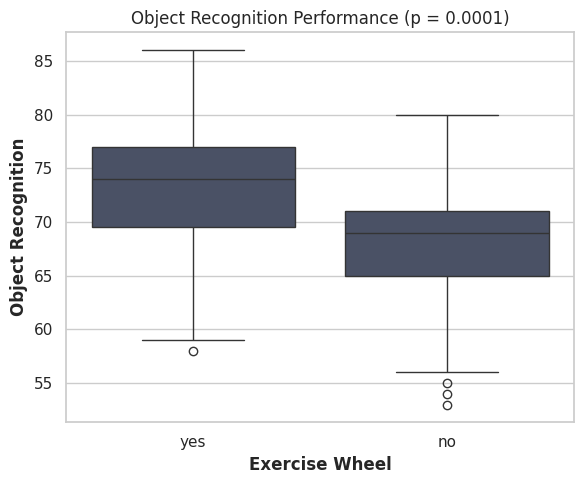

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))



sns.boxplot(data=mice, x='exercise_wheel', y='object_recognition', ax=axes, color="#454f69")

control_no = mice[mice['exercise_wheel'] == 'no']['object_recognition']
Alt_yes = mice[mice['exercise_wheel'] == 'yes']['object_recognition']
_, p_ttest = stats.ttest_ind(Alt_yes, control_no)

axes.set_title('Object Recognition Performance' + ' (p = ' + str(round(p_ttest, 4)) + ')')
axes.set_ylabel('Object Recognition', fontweight='bold')
axes.set_xlabel('Exercise Wheel', fontweight='bold')

plt.tight_layout()
plt.show()


 The t-test showed that mice who had access to exercise wheels performed significantly better in the object recognition test, t(118) = 4.03, p < 0.001.
